# Isolation with Migration (IM) Model

I notebook 04 byggede jeg en two-island model med konstant migration bagud i tid. På et tidspunkt i fortiden var de to bavian-populationer en fælles ancestral population Isolation with Migration (IM) modellen indfører dette:

- **Nutid $\rightarrow$ split-tid $t_s$:** to separate populationer med migration
- **Split-tid $t_s$ $\rightarrow$ fortid:** en fælles ancestral population (ingen migration)

Dette er en time-inhomogen model, raterne ændrer sig på et fast tidspunkt. Phasic gør dette via *epoch-baseret konstruktion* (se notebook 06 for detaljer). I denne notebook bruger jeg metoden direkte til IM-modellen.

I artiklen af Sørensen et al. (2023) ser man at *P. anubis* (olive) og *P. cynocephalus* (yellow) har et estimeret split for ca. 1 mio. år siden, efterfulgt af løbende admixture i den sydlige del af Tanzania. IM-modellen giver mig mulighed for både at estimere split-tid og post-split migration.

I denne notebook vil jeg komme ind på følgende: 

1. Epoch konstruktion
2. Byg IM-modellen med $2$ epoker
3. Teoretiske egenskaber — momenter og SFS
4. Simuler data med *msprime* 
5. SVGD inferens på simulerede data
6. Anvendelse på bavian-data (Southern olive vs. Eastern yellow)
7. Fortolkning — split-tid i generationer og år.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # Brug kun GPU 0 (eller fjern linjen på CPU-maskiner)
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

# phasic importeres først for at sætte JAX-backend korrekt
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, set_log_level,
)
set_log_level("WARNING")

import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement

%config InlineBackend.figure_format = "svg"

try:
    from vscodenb import set_vscode_theme
    set_vscode_theme()
except ImportError:
    pass

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
sns.set_palette("tab10")

MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

## 1. Epoch baseret konstruktion

Jeg bygger en epoch grafen. Hver state får en ekstra *epoch*-slot der identificerer hvilken epoke den tilhører, og overgange mellem epoker sker med rater der vælges ud fra sandsynligheden for at befinde sig i hver state.

*add_epoch* er vigtig, den:

1. Beregner sandsynligheden for at afslutte forrige epoke i hver transient state
2. Tilføjer "søsterstater" i næste epoke 
3. Udvider grafen med samme callback, men med opdateret *epoch_idx*

In [2]:
def add_epoch(graph, callback, epochs, epoch_idx, indexer):
    # Udvider grafen med en ny epoke ved at route linjer der stadig er aktive over til søsterstater i den nye epoke.
    epoch = epochs[epoch_idx]
    stop_probs = np.array(graph.stop_probability(epoch))
    accum_v_time = np.array(graph.accumulated_occupancy(epoch))

    with np.errstate(invalid="ignore"):
        epoch_trans_rates = stop_probs / accum_v_time

    for i in range(1, graph.vertices_length() - 1):
        if epoch_trans_rates is None or np.isnan(epoch_trans_rates[i]):
            continue
        if graph.vertex_at(i).edges_length() == 0:
            continue

        vertex = graph.vertex_at(i)
        state = vertex.state()

        if not state[indexer.epoch] == epoch_idx - 1:
            continue

        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child = graph.find_or_create_vertex(sister_state)
        coeff = np.zeros(graph.param_length())
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)

    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)

## 2. Byg IM-modellen

State-design:

- *descendants* — hvor mange samples en lineage bærer (til SFS)
- *in_pop* — hvilken population lineagen befinder sig i ($1$ eller $2$)
- *epoch* — $0$ = nutid $\rightarrow$ $t_s$ (to populationer med migration), $1$ = $t_s$ $\rightarrow$ fortid (ancestral, populationer merged)

Parametre (i coalescent-enheder):

| Index | Parameter            | Beskrivelse                        |
|-------|----------------------|------------------------------------|
| $0$     | $1/N_1$              | Coalescence-rate i population $1$    |
| $1$     | $1/N_2$              | Coalescence-rate i population $2$    |
| $2$     | $m$                  | Migrationsrate pr. lineage (epoch $0$) |
| $3$     | $1/N_a$              | Coalescence-rate i ancestral pop   |
| $4$     | —                    | Epoch-switch slot (sættes af *add_epoch*) |

**Konvention for epoch $1$ (post-split / ancestral):**
Efter split-tiden er de to populationer smeltet sammen til en ancestral population. Jeg modellerer dette ved at tillade coalescence mellem linjer uanset *in_pop*-label** (altså også mellem en pop-$1$-linje og en pop-$2$-linje). Migrationen slås fra. På den måde beholder jeg *in_pop*. som hvor var linjen på nutidstidspunktet, men den funktionelle forskel forsvinder.

In [3]:
nr_samples = 4

indexer = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ],
    slots=["epoch"],
)

# Start: alle n lineages i population 1, epoch 0
ipv = [0] * indexer.state_length
ipv[indexer.props_to_index(descendants=1, in_pop=1)] = nr_samples

N_PARAMS = 5   

def im_callback(state, epochs=None, epoch_idx=None, indexer=None):
    transitions = []
    epoch_idx = int(epoch_idx)

    if state[indexer.epoch] != epoch_idx:
        return transitions

    # Summerer kun over lineage-kolonner (ikke epoch-slot)
    lineage_sum = sum(state[k] for k in range(indexer.state_length) if k != indexer.epoch)
    if lineage_sum <= 1:
        return transitions

    # Coalescence
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)

        if epoch_idx == 0 and pi.in_pop != pj.in_pop: 
            continue

        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue

        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue

        k = indexer.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = np.zeros(N_PARAMS)
        if epoch_idx == 0:
            coeff[0 if pi.in_pop == 1 else 1] = rate
        else:  
            coeff[3] = rate    # ancestral population
        transitions.append([new, coeff])

    # Migration (kun i epoch 0) 
    if epoch_idx == 0:
        for i in range(indexer.state_length):
            if i == indexer.epoch: continue
            if state[i] == 0: continue
            pi = indexer.lineages.index_to_props(i)
            other = 2 if pi.in_pop == 1 else 1
            new = state.copy()
            new[i] -= 1
            k = indexer.props_to_index(descendants=pi.descendants, in_pop=other)
            new[k] += 1
            coeff = np.zeros(N_PARAMS)
            coeff[2] = state[i] # m
            transitions.append([new, coeff])

    return transitions

In [4]:
# epochs: start-tider. Epoch 0 starter ved t=0, epoch 1 ved t=t_split.
t_split = 1.0
epochs = [0.0, t_split]

# Sande parametre
N1_true, N2_true = 1.0, 2.0
m_true           = 0.8
Na_true          = 1.5
theta_true       = [1/N1_true, 1/N2_true, m_true, 1/Na_true, 1.0]

# Byg epoch-0-delen
graph_im = Graph(
    im_callback,
    ipv=ipv,
    epochs=epochs,
    epoch_idx=0,
    indexer=indexer,
)
graph_im.update_weights(theta_true)

# Udvid med epoch 1 (ancestral)
add_epoch(graph_im, im_callback, epochs, 1, indexer)
graph_im.update_weights(theta_true)

print(f"Antal vertices i IM-grafen: {graph_im.vertices_length()}")
print(f"Antal parametre:            {graph_im.param_length()}")

Antal vertices i IM-grafen: 41
Antal parametre:            5


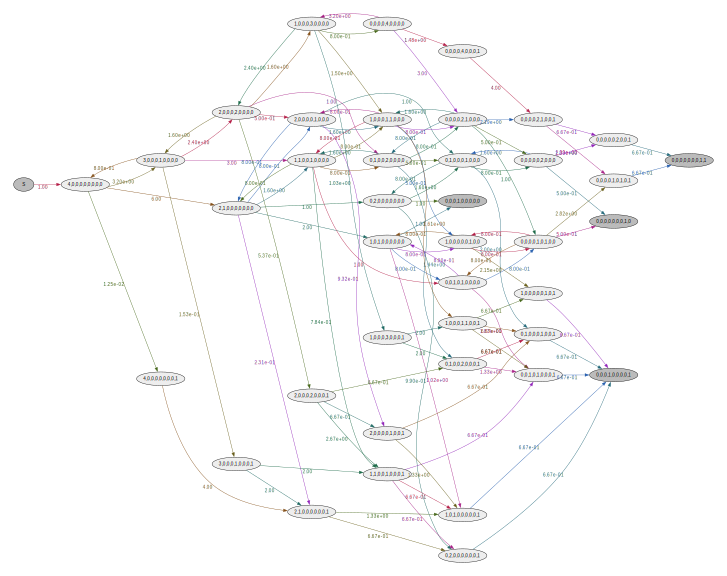

In [5]:
# Visualiser grafen
graph_im.plot(size=(12, 8), wrap=False, max_nodes=200)

## 3. Teoretiske egenskaber

Med sande parametre beregner jeg forventet TMRCA og højere momenter.

In [6]:
moments = graph_im.moments(4)
print("Momenter (første 4) i sande parametre:")
for k, m in enumerate(moments, start=1):
    print(f"  E[T^{k}] = {m:.4f}")

print(f"\nForventet TMRCA:    {moments[0]:.4f}")
print(f"Varians:            {moments[1] - moments[0]**2:.4f}")

Momenter (første 4) i sande parametre:
  E[T^1] = 1.5354
  E[T^2] = 4.3970
  E[T^3] = 19.4654
  E[T^4] = 116.3730

Forventet TMRCA:    1.5354
Varians:            2.0395


### Effekt af splot-tid $t_s$
Split-tidspunktet er en af de vigtigste og sværeste parametre at estimere.
Jeg undersøger, hvordan de teoretiske momenter og forventet TMRCA ændrer sig med $t_s$ for at forstå modellens sensitivitet.

Effekt af split-tid på teoretiske momenter:
 t_split  E[TMRCA]  Var[TMRCA]
     0.5    1.5149     -0.7800
     1.0    1.5354     -0.8221
     1.5    1.6103     -0.9828
     2.0    1.6425     -1.0554
     3.0    1.5988     -0.9573


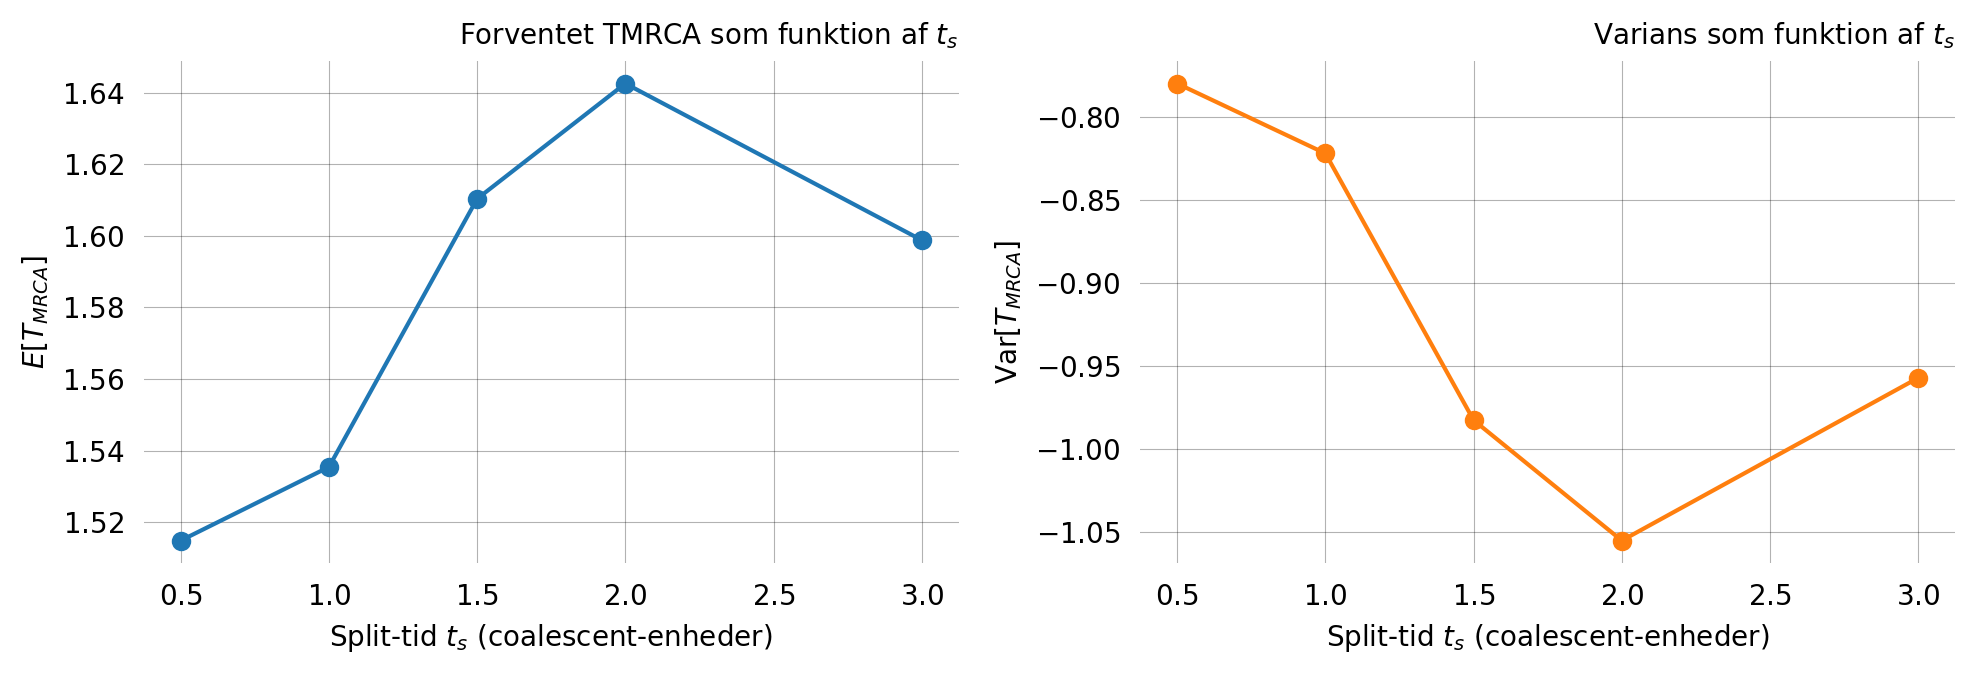


Fortolkning: Øget split-tid øger TMRCA — jo ældre splittet er,
desto mere tid er der til at coalesce i ancestral-populationen.


In [7]:
t_splits_test = [0.5, 1.0, 1.5, 2.0, 3.0]
results_ts = []

for ts in t_splits_test:
    epochs_ts = [0.0, ts]
    g_ts = Graph(
        im_callback,
        ipv=ipv,
        epochs=epochs_ts,
        epoch_idx=0,
        indexer=indexer,
    )
    theta_ts = [1/N1_true, 1/N2_true, m_true, 1/Na_true, 1.0]
    g_ts.update_weights(theta_ts)
    add_epoch(g_ts, im_callback, epochs_ts, 1, indexer)
    g_ts.update_weights(theta_ts)
    E_T = g_ts.moments(1)[0]
    Var_T = g_ts.moments(2)[0] - E_T**2
    results_ts.append({"t_split": ts, "E[TMRCA]": E_T, "Var[TMRCA]": Var_T})

df_ts = pd.DataFrame(results_ts)
print("Effekt af split-tid på teoretiske momenter:")
print(df_ts.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(df_ts["t_split"], df_ts["E[TMRCA]"], marker='o', color='C0')
axes[0].set_xlabel("Split-tid $t_s$ (coalescent-enheder)")
axes[0].set_ylabel("$E[T_{MRCA}]$")
axes[0].set_title("Forventet TMRCA som funktion af $t_s$")

axes[1].plot(df_ts["t_split"], df_ts["Var[TMRCA]"], marker='o', color='C1')
axes[1].set_xlabel("Split-tid $t_s$ (coalescent-enheder)")
axes[1].set_ylabel("$\\text{Var}[T_{MRCA}]$")
axes[1].set_title("Varians som funktion af $t_s$")

plt.tight_layout()
plt.show()

print("\nFortolkning: Øget split-tid øger TMRCA — jo ældre splittet er,")
print("desto mere tid er der til at coalesce i ancestral-populationen.")

## 4. Simuler data med msprime (IM-demografi)

For at validere inferensen simulerer jeg fra en IM-demografi og tjekker at jeg kan genskabe parametrene.

In [8]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
demography.add_population(name="ancestral", initial_size=anc_pop_size)
demography.add_population_split(time=1000, derived=["pop1", "pop2"], ancestral="ancestral")
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                           demography=demography, recombination_rate=rec_rate, 
                           sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("IM_model_derived_counts.csv", index=False)

In [9]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("IM_model_derived_counts.csv")

col = "pos" # Kan også bruge "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,121835,126784,2,1
1,130693,135293,2,2
2,962978,967549,2,1
3,1645140,1650545,3,4
4,1679198,1684665,1,2


In [10]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,121835,126784,2,1
1,130693,135293,2,2
2,962978,967549,2,1
3,1645140,1650545,3,4
4,1679198,1684665,1,2


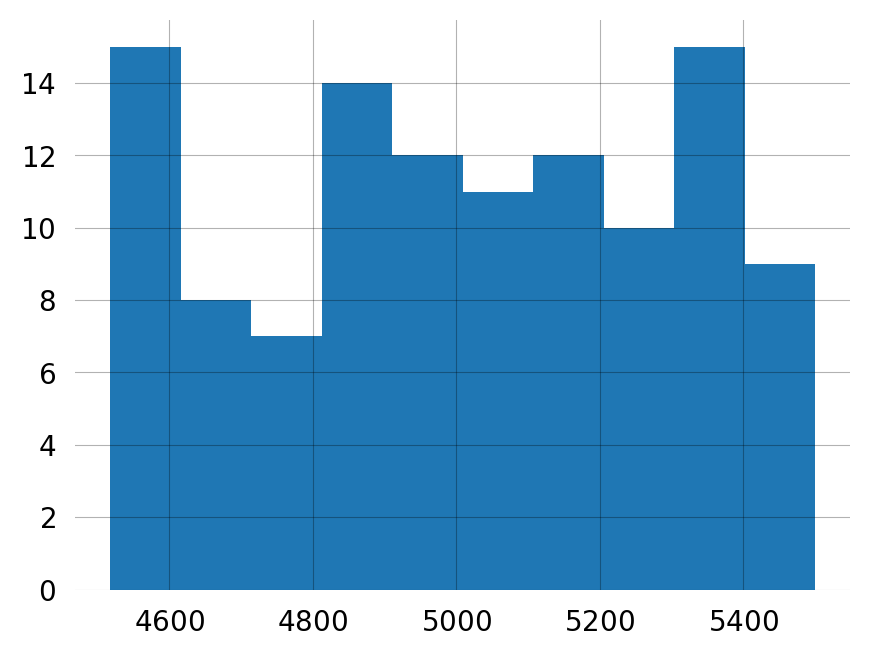

In [11]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [12]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [13]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## 5. Joint-probability graf og SVGD-inferens

Jeg laver en joint-probability graf baseret på SFS-komponenter og fitter modellen via SVGD.

IM-modellen med flere parametre og epoker er sværere at identificere end den simple two-island model. Man har typisk brug for flere samples eller flere uafhængige loci for stabil inferens.

In [14]:
try:
    import msprime
    have_msprime = True
except ImportError:
    have_msprime = False
    print("msprime ikke installeret — springer simulation over.")

def simulate_IM(n_samples, N1, N2, Na, t_split, m_per_gen,
                seq_len=2e7, mut_rate=1e-8, rec_rate=1e-8, seed=42):
    dem = msprime.Demography()
    dem.add_population(name="pop1",      initial_size=N1)
    dem.add_population(name="pop2",      initial_size=N2)
    dem.add_population(name="ancestral", initial_size=Na)
    dem.set_migration_rate(source="pop1", dest="pop2", rate=m_per_gen)
    dem.set_migration_rate(source="pop2", dest="pop1", rate=m_per_gen)
    dem.add_population_split(time=t_split, derived=["pop1", "pop2"], ancestral="ancestral")

    ts = msprime.sim_ancestry(
        samples={"pop1": n_samples, "pop2": 0},
        ploidy=1,
        demography=dem,
        recombination_rate=rec_rate,
        sequence_length=seq_len,
        random_seed=seed,
    )
    ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=seed + 1)
    return ts

Ne_REF = 10_000
t_split_gens = 2 * Ne_REF * epochs[1]   # coalescent-enheder → generationer

if have_msprime:
    ts = simulate_IM(
        n_samples=nr_samples,
        N1=Ne_REF * N1_true,
        N2=Ne_REF * N2_true,
        Na=Ne_REF * Na_true,
        t_split=t_split_gens,
        m_per_gen=m_true / (2 * Ne_REF),
    )
    print(f"Simuleret: {ts.num_trees} træer, {ts.num_mutations} mutationer")

Simuleret: 9840 træer, 14087 mutationer


In [15]:
mutation_rate = 1.0
joint_graph = graph_im.joint_prob_graph(
    indexer,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate,
)

# Mutations-parameter tilføjes som sidste slot
theta_joint = list(theta_true) + [mutation_rate]
joint_graph.update_weights(theta_joint)

tbl = joint_graph.joint_prob_table()
print(f"Antal unikke mønstre: {len(tbl)}")
print(f"Deficit:              {(1 - tbl['prob'].sum()).item():.4f}")
tbl.head(8)

Antal unikke mønstre: 14
Deficit:              0.8281


,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
179,0,0,0,0,0.033617
180,0,0,0,0,0.023450
181,0,1,0,0,0.009076
182,1,0,0,0,0.024923
183,0,0,1,0,0.004683
184,0,1,0,0,0.013855
185,1,0,0,0,0.029553
186,0,0,1,0,0.009251


In [16]:
def ktons_to_obs(k_array, table, n_samples):
    feature_cols = [c for c in table.columns if c.startswith("descendants")]
    allowed = set(tuple(int(x) for x in r) for r in table[feature_cols].values)
    obs = []
    for k in k_array:
        o = [0] * len(feature_cols)
        if 0 < k - 1 < len(o):
            o[k - 1] = 1
        if tuple(o) in allowed:
            obs.append(o)
    return obs

if have_msprime:
    k_sim = np.array([int(v.genotypes.sum()) for v in ts.variants()])
    k_sim = k_sim[(k_sim > 0) & (k_sim < nr_samples)]
    obs_sim = ktons_to_obs(k_sim, tbl, nr_samples)
    print(f"Simulerede observationer: {len(obs_sim):,}")

Simulerede observationer: 12,231


In [17]:
# Parameter-indeks i joint_graph:
#   0: 1/N1, 1: 1/N2, 2: m, 3: 1/Na, 4: epoch-switch, 5: mutations-rate
# Både epoch-switch og mutationsrate er "ikke-fri" parametre: de fastholdes.
MUT_IDX          = joint_graph.param_length() - 1
EPOCH_SWITCH_IDX = MUT_IDX - 1
EPOCH_SWITCH_VAL = 1.0    # sættes af add_epoch via coeff=1 på sidste slot

# None i prior-listen er kun tilladt for parametre der står i `fixed`.
prior_list = [
    GaussPrior(ci=[0.2, 4.0]),   # 1/N1
    GaussPrior(ci=[0.2, 4.0]),   # 1/N2
    GaussPrior(ci=[0.0, 3.0]),   # m
    GaussPrior(ci=[0.2, 4.0]),   # 1/Na
    None,                         # epoch-switch (fikseret)
    None,                         # mutation (fikseret)
][:joint_graph.param_length()]

fixed_list = [
    (EPOCH_SWITCH_IDX, EPOCH_SWITCH_VAL),
    (MUT_IDX,          mutation_rate),
]

if have_msprime and len(obs_sim) > 500:
    svgd_sim = joint_graph.svgd(
        observed_data=obs_sim[:5000],
        fixed=fixed_list,
        n_iterations=120,
        n_particles=80,
        prior=prior_list,
        learning_rate=ExpStepSize(first_step=0.06, last_step=0.01, tau=40.0),
    )
    svgd_sim.summary(ci_method="hpd", ci_level=0.95)

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         5.0677     3.6704     1.2161     1.2762       5.1939      
1          No         1.4806     2.0960     1.0699     0.5659       4.1694      
2          No         2.9146     2.0038     0.8147     0.1014       2.9700      
3          No         3.0106     2.4753     0.7772     0.8826       3.6508      
4          Yes        1.0000     NA         NA         NA           NA          
5          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 120


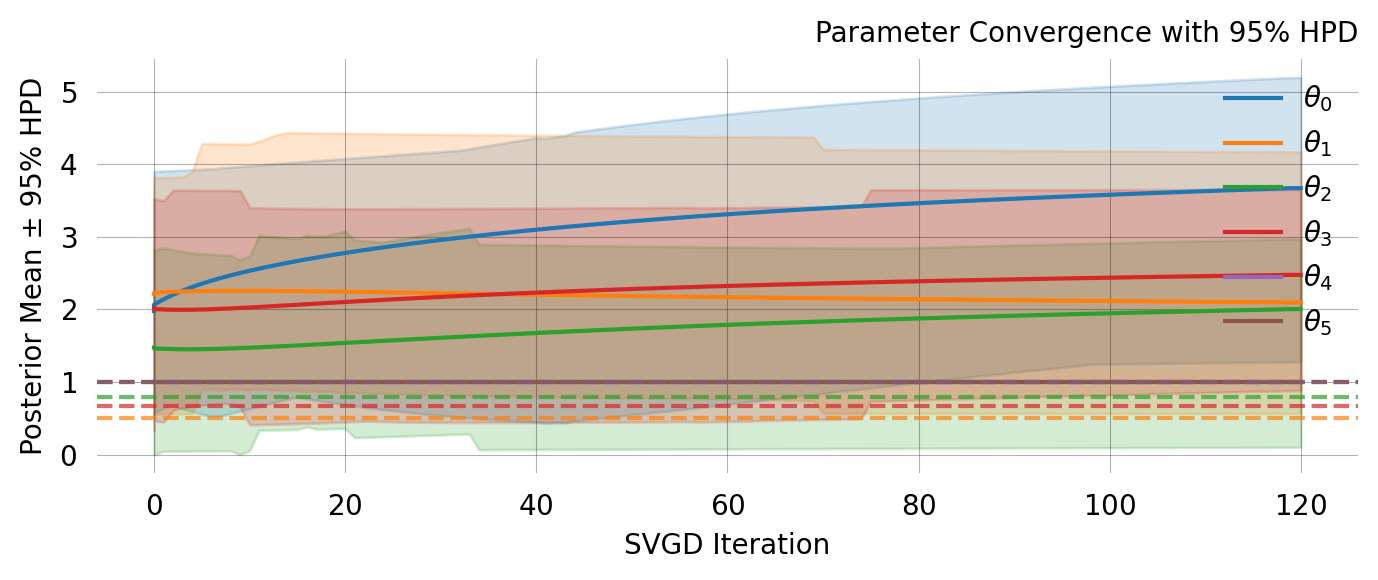

<Figure size 500x370 with 0 Axes>

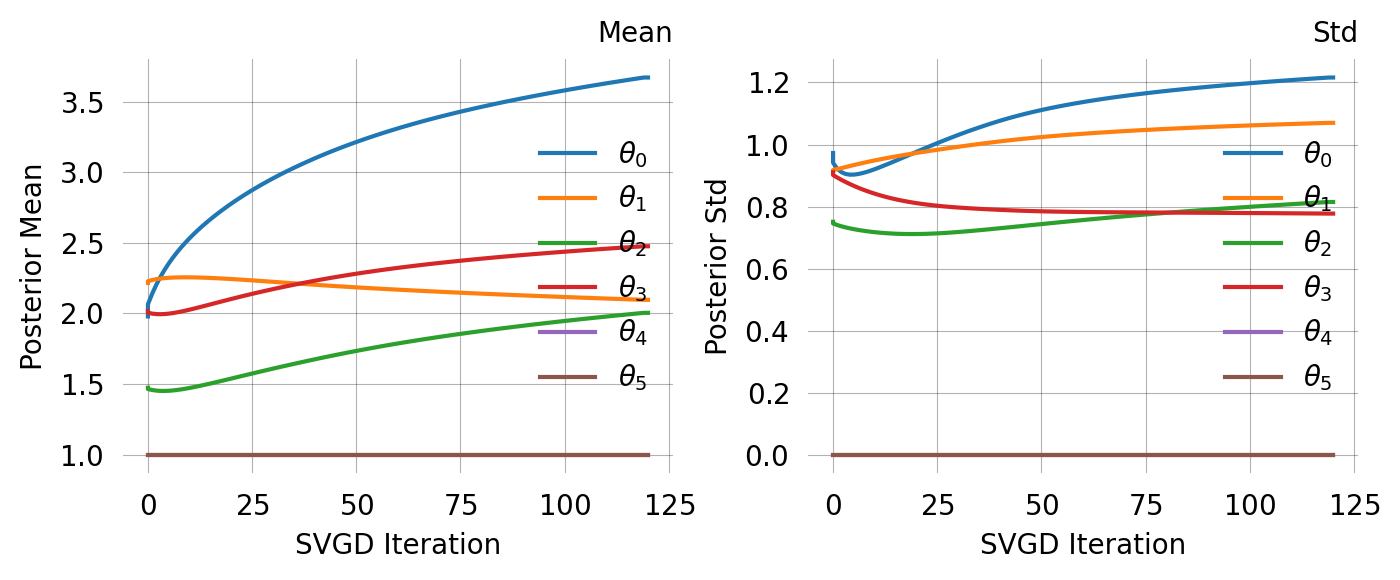

In [18]:
if have_msprime and len(obs_sim) > 500:
    svgd_sim.plot_ci(ci_method="hpd", true_theta=theta_joint)
    plt.suptitle("Posterior CI — IM simulation")
    plt.show()

    svgd_sim.plot_convergence()

## 6. Anvendelse på bavian-data

Sørensen et al. ($2023$) dokumenterer løbende admixture mellem *Southern olive* (Tarangire) og *Eastern yellow* (Mikumi). Jeg fitter IM-modellen på en af dem, her *Southern olive*.


In [19]:
def load_baboon_ktons(path, n_samples_use, seed=0):
    p = Path(path)
    if not p.exists():
        print(f"[advarsel] {p} findes ikke — kør notebook 03 først.")
        return None
    df = pd.read_csv(p)
    df = df[df["nr_samples"] >= n_samples_use].copy()
    if len(df) == 0:
        print(f"[advarsel] {p} har ingen varianter med nr_samples >= {n_samples_use}")
        return None
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=n_samples_use,
    )
    k = k[(k > 0) & (k < n_samples_use)]
    return k

k_oliv = load_baboon_ktons(OUT_DIR / "derived_counts_olive_south.csv", nr_samples)

if k_oliv is not None:
    obs_oliv = ktons_to_obs(k_oliv, tbl, nr_samples)
    print(f"Southern olive: {len(obs_oliv):,} brugbare observationer")

Southern olive: 268,757 brugbare observationer


Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         4.9693     3.8104     1.0384     1.6708       5.1060      
1          No         0.7300     2.8242     1.4818     0.0000       5.0978      
2          No         2.4050     1.9251     0.7740     0.0000       2.5549      
3          No         3.1408     3.1248     0.8553     1.2536       4.3691      
4          Yes        1.0000     NA         NA         NA           NA          
5          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 120


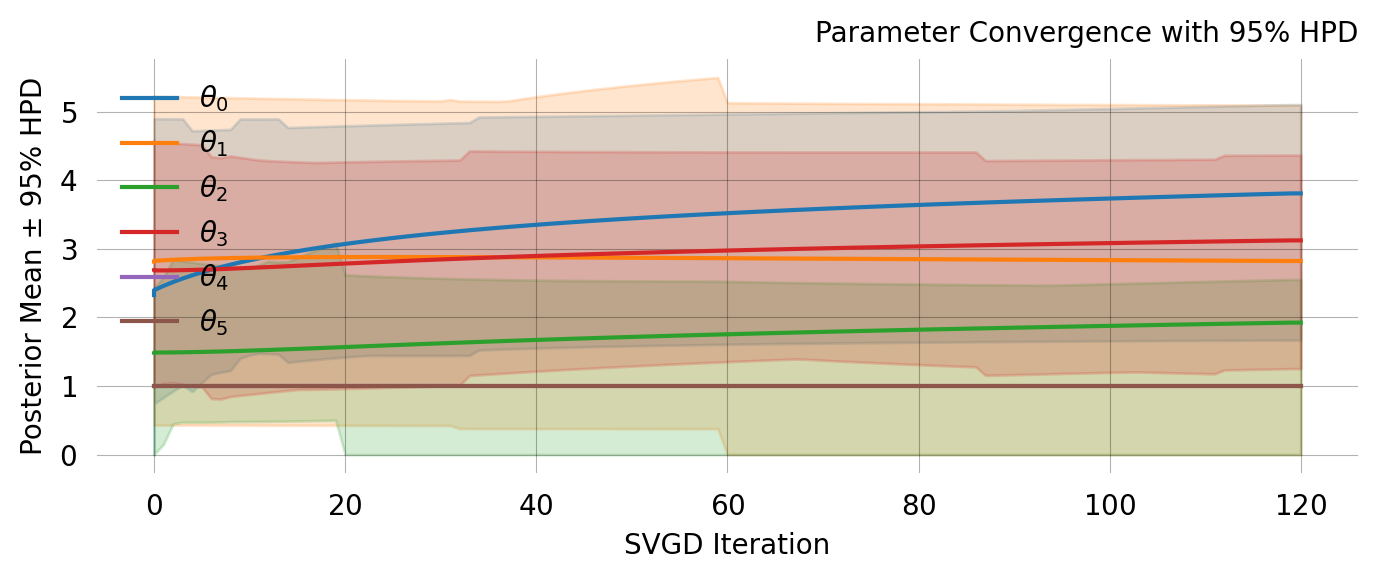

<Figure size 500x370 with 0 Axes>

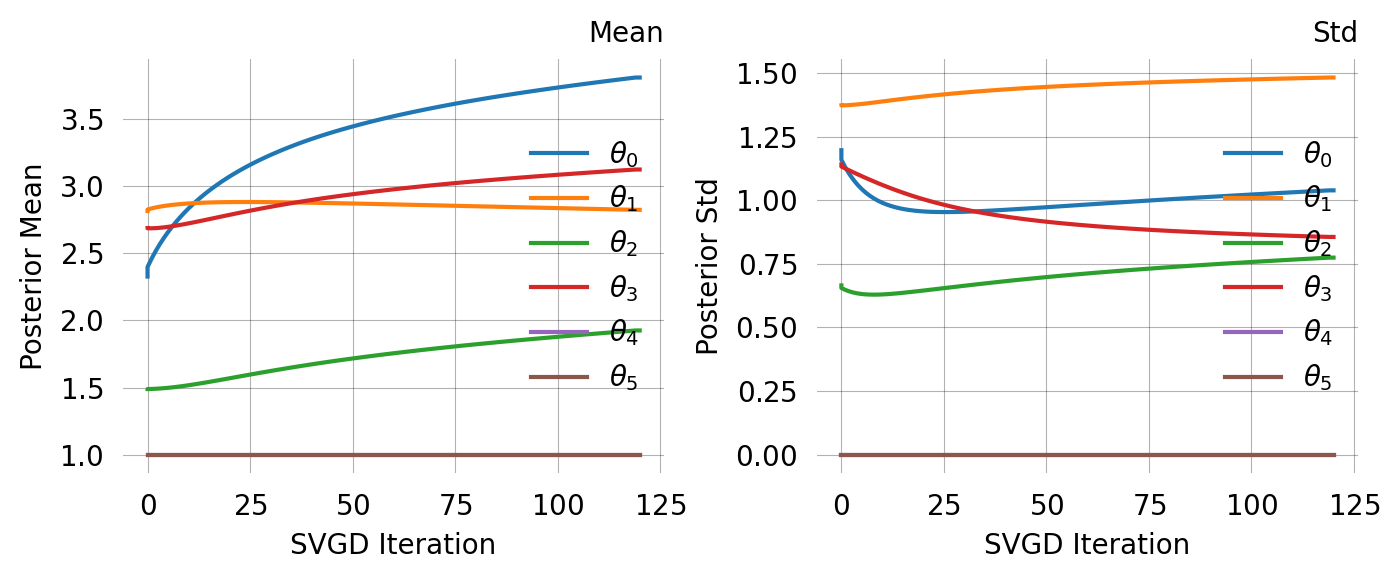

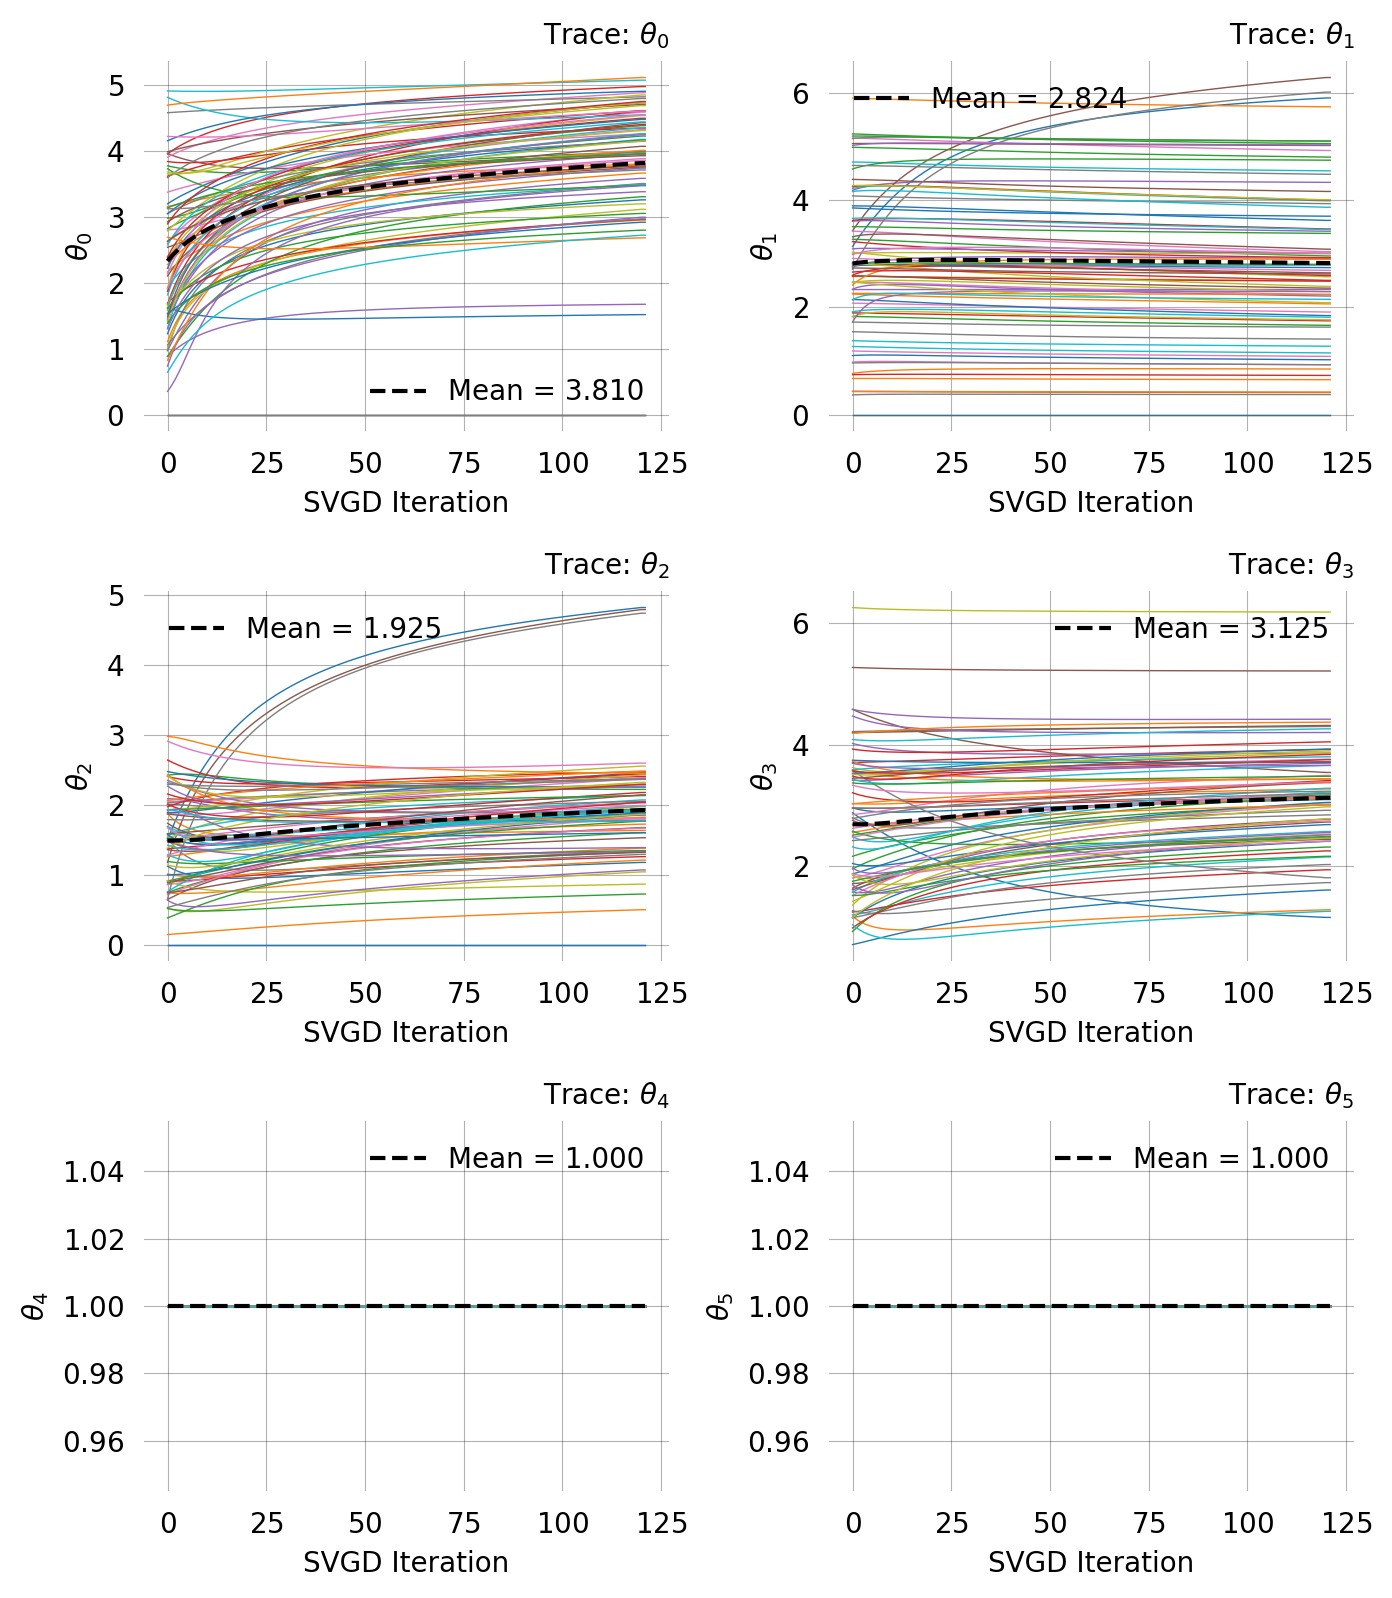

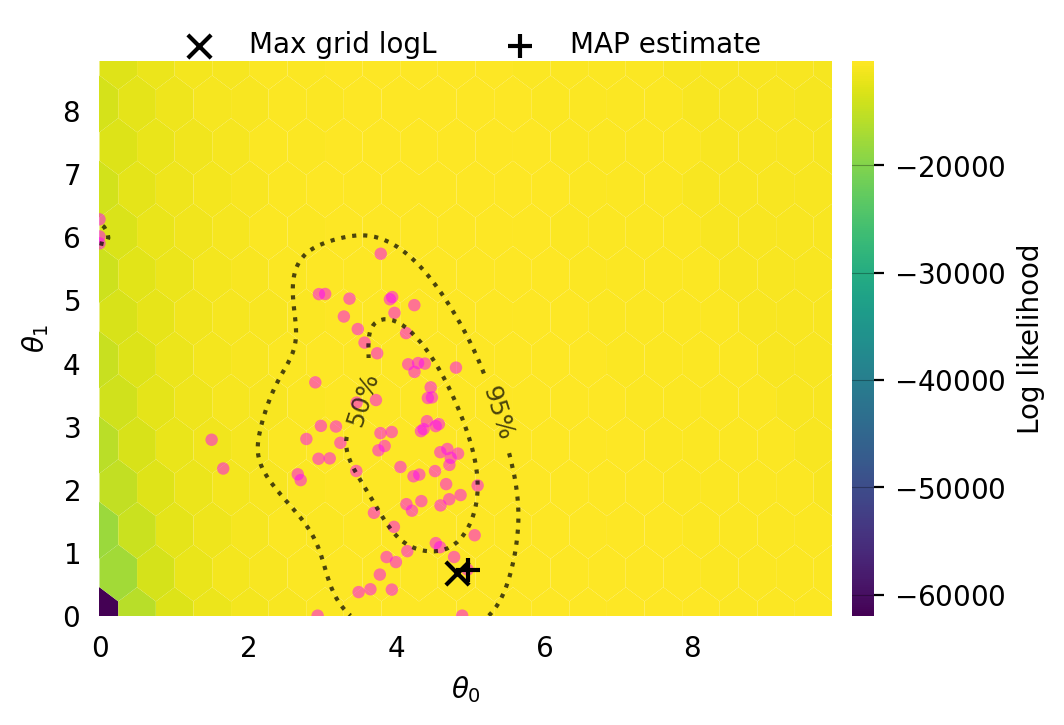

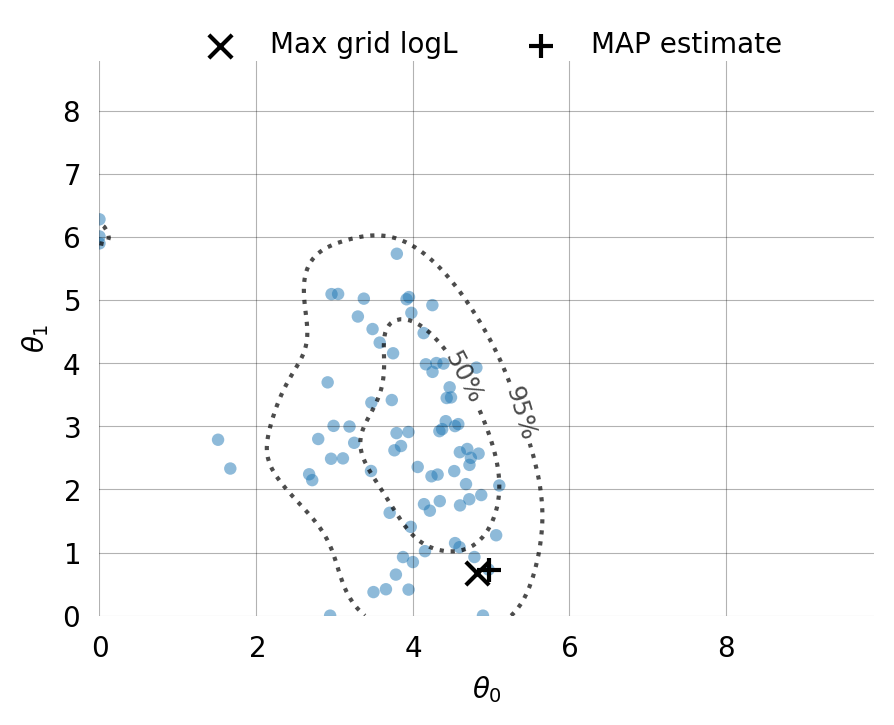

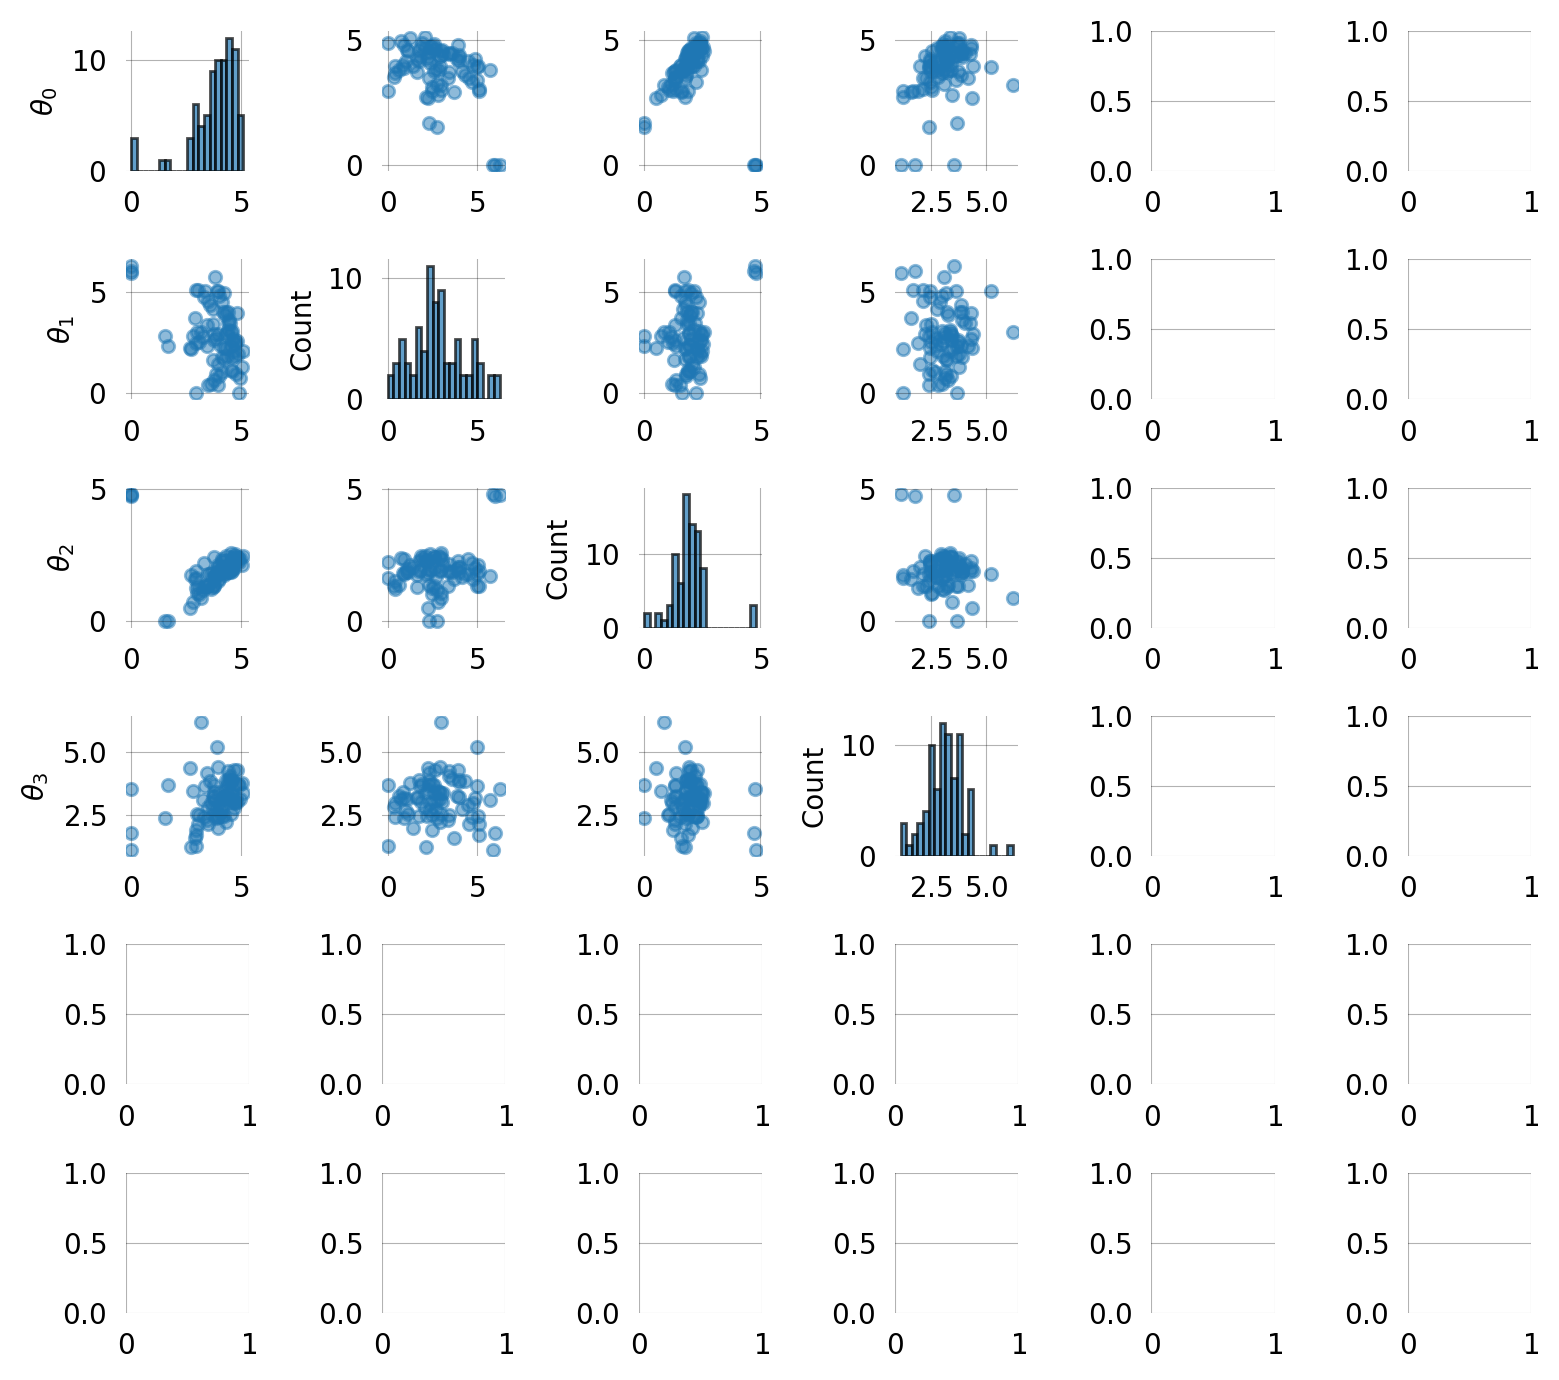

<Figure size 500x370 with 0 Axes>

In [20]:
if k_oliv is not None and len(obs_oliv) > 1000:
    rng = np.random.default_rng(1)
    if len(obs_oliv) > 5000:
        idx = rng.choice(len(obs_oliv), 5000, replace=False)
        obs_oliv_use = [obs_oliv[i] for i in idx]
    else:
        obs_oliv_use = obs_oliv

    prior_list_baboon = [
        GaussPrior(ci=[0.1, 5.0]),
        GaussPrior(ci=[0.1, 5.0]),
        GaussPrior(ci=[0.0, 3.0]),
        GaussPrior(ci=[0.2, 5.0]),
        None,
        None,
    ][:joint_graph.param_length()]

    svgd_baboon = joint_graph.svgd(
        observed_data=obs_oliv_use,
        fixed=fixed_list,
        n_iterations=120,
        n_particles=80,
        prior=prior_list_baboon,
        learning_rate=ExpStepSize(first_step=0.06, last_step=0.01, tau=40.0),
    )
    svgd_baboon.summary(ci_method="hpd", ci_level=0.95)

    svgd_baboon.plot_ci(ci_method="hpd")
    plt.suptitle("Posterior — Southern olive (IM-model)")
    plt.show()

    svgd_baboon.plot_convergence();
    
    svgd_baboon.plot_trace()

    svgd_baboon.plot_hdr()

    svgd_baboon.plot_hdr(hexgrid=False) ;

    svgd_baboon.plot_pairwise()
    plt.suptitle("Posterior pairwise — Southern olive", y=1.02)
    plt.show()


## Resultat tabel 

In [21]:
pi_df = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)
pi_val = pi_df.loc["Southern olive", "pi"]
Ne_ref = pi_val / (4 * MUT_RATE)

res = svgd_baboon.get_results()
theta = res['theta_mean']


N1 = (1/theta[0]) * Ne_ref
N2 = (1/theta[1]) * Ne_ref
Na = (1/theta[3]) * Ne_ref
m_gen = theta[2] / (2 * Ne_ref)
t_years = epochs[1] * 2 * Ne_ref * GEN_TIME

print(f"Referencepopulationsstørrelse (N_ref): {Ne_ref:,.0f}")
print()
print("IM-model estimater:")
print(f"  N1 (Southern olive):    {N1:,.0f} individer  [theta={theta[0]:.3f}]")
print(f"  N2 (Eastern yellow):    {N2:,.0f} individer  [theta={theta[1]:.3f}]")
print(f"  N_ancestral:            {Na:,.0f} individer  [theta={theta[3]:.3f}]")
print(f"  Migration (m):          {m_gen:.2e} /generation [theta={theta[2]:.3f}]")
print(f"  Split-tid:              {t_years:,.0f} år")
print()
print(f"  Sammenlign: Sørensen et al. (2023) estimerer split ~1 mio. år siden")

Referencepopulationsstørrelse (N_ref): 54,704

IM-model estimater:
  N1 (Southern olive):    14,357 individer  [theta=3.810]
  N2 (Eastern yellow):    19,370 individer  [theta=2.824]
  N_ancestral:            17,507 individer  [theta=3.125]
  Migration (m):          1.76e-05 /generation [theta=1.925]
  Split-tid:              1,203,497 år

  Sammenlign: Sørensen et al. (2023) estimerer split ~1 mio. år siden


I notebook 06 udforsker jeg time-inhomogeneity i dybden og sammenligner phasic's numeriske tilgang med Pool og Nielsens analytiske formler.